# 연구를 위한 Deep Agent 설계(Deep Agent for Research)

이전까지 알아본 모든 내용을 종합하여 Deep Agent를 완성합니다.

**Context Offloading**, **Sub-agent Delegation**, **Strategic Thinking** 을 결합하여 복잡한 리서치 워크플로우를 최적화하는 방법을 다룹니다.

**🏆 핵심 내용**

*   **Deep Agent 아키텍처**: 파일 기반 컨텍스트 관리 및 토큰 효율화
*   **Search Tool**: Tavily API 연동, 웹페이지 요약, 파일 저장
*   **Think Tool**: 리서치 진행 상황 분석 및 전략적 의사결정 도구
*   **Sub-agent**: Research Sub-agent 구성 및 작업 위임

## Deep Agent 아키텍처 및 도구 설계

![agent_header](./assets/agent_header.png)

**핵심 구조**

*   **TODO List**: 작업 진행 상황 관리
*   **File System**: 원본 데이터 저장 (Context Offloading)
*   **Sub-agent**: 리서치 작업 위임 및 컨텍스트 분리

## 도구(Research)

이 모듈은 리서치 에이전트를 위한 검색 및 콘텐츠 처리 유틸리티 제공.
웹 검색 기능 및 콘텐츠 요약 도구 포함.

### Search Tool 설계

웹 검색 결과를 파일로 저장하고 요약본만 에이전트에게 전달하여 토큰 효율성을 극대화합니다.

*   **`run_tavily_search`**: Tavily API 기반 웹 검색
*   **`summarize_webpage_content`**: gpt 활용 구조적 요약 및 파일명 생성
*   **`process_search_results`**: HTML → Markdown 변환 및 결과 처리
*   **`tavily_search` (Tool)**: 검색-요약-저장 통합 프로세스, 최소 정보 반환
*   **`think_tool`**: 리서치 결과 분석 및 전략적 의사결정 지원

## 웹 검색 결과 컨텍스트 최적화를 위한 요약 파이프라인

요약된 결과 형식
- `filename`: 요약된 파일명
- `summary`: 요약된 내용

In [1]:
# 요약 프롬프트
from util.messages_in_jupyter import show_prompt

from deep_agents_from_scratch.prompts import SUMMARIZE_WEB_SEARCH_KOR

show_prompt(SUMMARIZE_WEB_SEARCH_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  연구 방향 조정을 위한 최소 요약을 작성하고 있습니다. 목표는 에이전트가 수집한 정보를                           │
│  알게 하는 것이지, 모든 세부 사항을 보존하는 것이 아닙니다.                                                     │
│                                                                                                                 │
│  <webpage_content>                                                                                              │
│  {webpage_content}                                                                                              │
│  </webpage_content>                                                                                             │
│                                                                                                                 │
│  다음에 초점을 맞춘 매우 간결한 요약을 작성하십시오:                                                            │
│  1. 1~2문장으로 된 주요 주제/대상                                                                               │
│  2. 핵심 정보 유형(사실, 튜토리얼, 뉴스, 분석 등)                                                               │
│  3. 가장 중요한 1~2가지 발견 또는 요점                                                                          │
│                                                                                                                 │
│  요약은 총 150단어 이내로 유지하십시오. 에이전트는 이 파일에 무엇이 있는지 알아야                               │
│  추가 검색을 할지 이 출처를 사용할지 결정할 수 있습니다.                                                        │
│                                                                                                                 │
│  내용 유형과 주제를 나타내는 설명적 파일명을 생성하십시오                                                       │
│  (예: "mcp_protocol_overview.md", "ai_safety_research_2024.md").                                                │
│                                                                                                                 │
│  출력 형식:                                                                                                     │
│  ```json                                                                                                        │
│  {{                                                                                                             │
│     "filename": "descriptive_filename.md",                                                                      │
│     "summary": "주요 주제와 핵심 발견에 초점을 맞춘 150단어 이내의 매우 짧은 요약"                              │
│  }}                                                                                                             │
│  ```                                                                                                            │
│                                                                                                                 │
│  오늘 날짜: {date}                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### 🔍 연구 진행과 의사결정을 위한 전략적 성찰 도구 (think tool)

검색을 할 때마다 이 도구를 사용해 결과를 분석하고 다음 단계를 체계적으로 계획하세요. 연구 워크플로에 의도적인 멈춤(Pause)을 넣어, 질 높은 판단을 내리도록 합니다.

#### 📍 사용 시점

* **검색 결과를 받은 뒤:** 어떤 핵심 정보를 찾았는가?
* **다음 단계를 정하기 전:** 포괄적으로 답하기에 충분한가?
* **연구 공백을 점검할 때:** 아직 어떤 구체적 정보가 부족한가?
* **연구를 마무리하기 전:** 지금 완전한 답을 줄 수 있는가?
* **질문의 복잡도 한계:** 검색 횟수 한도에 도달했는가?

#### 📝 성찰에 포함할 내용

1. **현재까지의 발견 분석** — 어떤 구체적 정보를 모았는가?
2. **공백 평가** — 여전히 빠진 핵심 정보는 무엇인가?
3. **품질 평가** — 좋은 답을 위해 근거와 예시가 충분한가?
4. **전략적 결정** — 검색을 이어갈 것인가, 답을 제시할 것인가?

---

#### ⚙️ 파라미터 (Args)

* **`reflection`**: 연구 진행, 발견, 공백, 다음 단계에 대한 상세한 성찰 내용

#### ↩️ 반환값 (Returns)

* 의사결정을 위해 성찰이 기록되었음을 확인하는 메시지

## Deep Agent 구성

리서치 에이전트의 전체 구조를 조립합니다.

*   **Research Sub-agent**: `tavily_search`, `think_tool` 할당 → 정보 탐색 및 분석 집중
*   **Parent Agent**: `task`(위임), `think_tool`, 파일 시스템 도구 할당 → 전체 조율 및 관리
*   **효과**: 명확한 역할 분리를 통한 복잡한 워크플로우의 체계적 관리

In [ ]:
# 리서처 에이전트 프롬프트 출력 (서브에이전트)
from deep_agents_from_scratch.prompts import RESEARCHER_INSTRUCTIONS_KOR


show_prompt(RESEARCHER_INSTRUCTIONS_KOR)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  당신은 사용자가 입력한 주제에 대해 연구를 수행하는 연구 보조입니다. 참고로 오늘 날짜는 {date}입니다.           │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  당신의 역할은 도구를 사용하여 사용자가 입력한 주제에 대한 정보를 수집하는 것입니다.                            │
│  연구 질문에 답하는 데 도움이 되는 자료를 찾기 위해 제공된 도구를 사용할 수 있습니다.                           │
│  직렬 또는 병렬로 호출할 수 있으며, 연구는 도구 호출 루프에서 수행됩니다.                                       │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  사용할 수 있는 두 가지 주요 도구:                                                                              │
│  1. **tavily_search**: 정보 수집을 위한 웹 검색 수행                                                            │
│  2. **think_tool**: 연구 중 반성 및 전략적 계획                                                                 │
│                                                                                                                 │
│  **중요: 각 검색 후 think_tool을 사용하여 결과를 반성하고 다음 단계를 계획하십시오**                            │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  시간이 제한된 인간 연구자처럼 생각하십시오. 다음 단계를 따르십시오:                                            │
│                                                                                                                 │
│  1. **질문을 주의 깊게 읽으십시오** - 사용자가 구체적으로 어떤 정보를 필요로 합니까?                            │
│  2. **넓은 검색부터 시작하십시오** - 먼저 넓고 포괄적인 쿼리를 사용하십시오                                     │
│  3. **각 검색 후 잠시 멈추고 평가하십시오** - 답변하기에 충분합니까? 무엇이 아직 부족합니까?                    │
│  4. **정보를 모으면서 더 좁은 검색을 실행하십시오** - 빈틈을 채우십시오                                         │
│  5. **자신 있게 답할 수 있을 때 중단하십시오** - 완벽을 위해 계속 검색하지 마십시오                             │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **도구 호출 예산** (과도한 검색 방지):                                                                         │
│  - **단순 쿼리**: 검색 도구 호출 최대 1~2회                                                                     │
│  - **일반 쿼리**: 검색 도구 호출 최대 2~3회                                                                     │
│  - **매우 복잡한 쿼리**: 검색 도구 호출 최대 5회                                                                │
│  - **항상 중단**: 적절한 출처를 찾지 못하면 검색 도구 호출 5회 후                                               │
│                                                                                                                 │
│  **다음 경우 즉시 중단**:                                                                                       │
│  - 사용자 질문에 포괄적으로 답할 수 있을 때                                                                     │
│  - 질문에 대한 관련 예시/출처가 3개 이상 있을 때                                                                │
│  - 마지막 2회 검색이 유사한 정보를 반환했을 때                                                                  │
│  <

In [ ]:
# TODO 관리, 파일 시스템 사용, 서브에이전트 위임 관련 프롬프트를 하나의 문자열로 통합
from deep_agents_from_scratch.prompts import *


INSTRUCTIONS = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_INSTRUCTIONS
)


# TODO 관리, 파일 시스템 사용, 서브에이전트 위임 관련 프롬프트를 하나의 문자열로 통합
INSTRUCTIONS_KOR = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS_KOR
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS_KOR
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_USAGE_INSTRUCTIONS_KOR
)

# 통합된 프롬프트를 화면에 출력하여 에이전트의 역할 및 사용법 안내
show_prompt(INSTRUCTIONS_KOR)


╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # TODO MANAGEMENT                                                                                              │
│  사용자 요청에 따라:                                                                                            │
│  1. 도구 설명에 따라 사용자 요청 시작 시 write_todos 도구를 사용하여 TODO를 생성하십시오.                       │
│  2. TODO를 완료한 후 read_todos를 사용하여 TODO를 읽고 계획을 상기하십시오.                                     │
│  3. 수행한 작업과 TODO에 대해 반성하십시오.                                                                     │
│  4. 작업을 completed로 표시하고 다음 TODO로 진행하십시오.                                                       │
│  5. 모든 TODO가 완료될 때까지 이 과정을 계속하십시오.                                                           │
│                                                                                                                 │
│  중요: 모든 사용자 요청에 대해 항상 TODO 연구 계획을 만들고 위 지침에 따라 연구를 수행하십시오.                 │
│  중요: 추적해야 할 TODO 수를 최소화하기 위해 연구 작업을 *단일 TODO*로 묶는 것을 목표로 하십시오.               │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # FILE SYSTEM USAGE                                                                                            │
│  컨텍스트를 유지하고 저장하는 데 도움이 되는 가상 파일 시스템에 접근할 수 있습니다.                             │
│                                                                                                                 │
│  ## 워크플로 절차                                                                                               │
│  1. **Orient**: 작업을 시작하기 전에 ls()로 기존 파일을 확인하십시오                                            │
│  2. **Save**: write_file()로 사용자 요청을 저장하여 나중에 보관할 수 있게 하십시오                              │
│  3. **Research**: 연구를 진행하십시오. 검색 도구가 파일을 작성합니다.                                           │
│  4. **Read**: 수집한 출처에 만족하면 파일을 읽고 사용자 질문에 직접 답하십시오.                                 │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # SUB-AGENT DELEGATION                                                                                         │
│  서브에이전트에 작업을 위임할 수 있습니다.                                                                      │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  당신의 역할은 구체적인 연구 작업을 서브에이전트에 위임하여 연구를 조정하는 것입니다.                           │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: 전문 서브에이전트에 연구 작업 위임                                    │
│     - description: 명확하고 구체적인 연구 질문 또는 작업                                                      

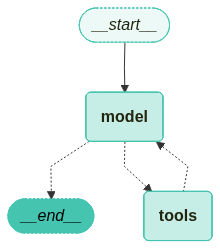

In [10]:
from deep_agents_from_scratch.deep_agent_full_graph import DeepAgentFullGraph

workflow = DeepAgentFullGraph()

workflow.show_graph()

In [11]:
from util.messages_in_jupyter import format_messages

# 에이전트에게 MCP 개요 요청 메시지 전달 및 응답 결과 저장
result = workflow.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

# 에이전트 응답 메시지 포맷팅 및 출력, 사용자 친화적 결과 확인 목적
format_messages(result["messages"])


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  write_todos (call_o9y78LllMsHSo89oiIM1YO0V)
 Call ID: call_o9y78LllMsHSo89oiIM1YO0V
  Args:
    todos: [{'content': 'Research and provide an overview of Model Context Protocol (MCP).', 'status': 'pending'}]

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{'content': 'Research and provide an overview of Model Context Protocol (MCP).', 'status': 'pending'}
================================= Tool Message =================================
Name: write_todos

Updated todo list (1 items) and saved to /Users/jyuka/workspace/LangGraph-Edu/deep_agents_from_scratch/.agent_data/todos.json

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  read_todos (call_OmA3asg9Nx4vXYAJA1aL2Uke)
 Call ID: call_OmA3asg9Nx4vX

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research and provide an overview of Model Context Protocol (MCP).",                           │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_o9y78LllMsHSo89oiIM1YO0V                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list (1 items) and saved to                                                                        │
│ /Users/jyuka/workspace/LangGraph-Edu/deep_agents_from_scratch/.agent_data/todos.json                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: call_OmA3asg9Nx4vXYAJA1aL2Uke                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I have gathered a comprehensive overview of the Model Context Protocol (MCP), including its    │
│ purpose, key features, and applications. The MCP aims to integrate AI assistants with various data sources      │
│ while maintaining context and ensuring user privacy. Key features include core server and client                │
│ functionalities, security measures, and integration support with popular platforms. This information is         │
│ sufficient to provide a complete answer to the user's request."                                                 │
│ }                                                                                                               │
│    ID: call_RdpmjImrYpprgzlxKd6bvy2H                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: I have gathered a comprehensive overview of the Model Context Protocol (MCP), including    │
│ its purpose, key features, and applications. The MCP aims to integrate AI assistants with various data sources  │
│ while maintaining context and ensuring user privacy. Key features include core server and client                │
│ functionalities, security measures, and integration support with popular platforms. This information is         │
│ sufficient to provide a complete answer to the user's request.                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research and provide an overview of Model Context Protocol (MCP).",                           │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_6eviJ31CB1LhukrqobSxhtro                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list (1 items) and saved to                                                                        │
│ /Users/jyuka/workspace/LangGraph-Edu/deep_agents_from_scratch/.agent_data/todos.json                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I have completed the research on the Model Context Protocol (MCP). Here’s an overview:                          │
│                                                                                                                 │
│ ### Model Context Protocol (MCP)                                                                                │
│                                                                                                                 │
│ **Purpose:**                                                                                                    │
│ MCP is an open-source standard designed to facilitate the integration of AI assistants with various data        │
│ sources and business systems. It aims to address the challenge of AI isolation from data by providing a unified │
│ protocol that enables AI systems to maintain context across different tools and datasets.                       │
│                                                                                                                 │
│ **Key Features:**                                                                                               │
│ 1. **Core Server Features:**                                                                                    │
│    - **Resources:** Access to data and context.                                                                 │
│    - **Prompts:** Templated workflows for consistent interactions.                                              │
│    - **Tools:** Execution of functions callable by the AI.                                                      │
│                                                                                                                 │
│ 2. **Client Features:**                                                                                         │
│    - **Sampling:** Generation of responses based on user interactions.                                          │
│    - **Roots:** Server-initiated interactions for enhanced responsiveness.                                      │
│                                                                                                                 │
│ 3. **Security Measures:**                                                                                       │
│    - Requires explicit user consent for data access and tool execution.                                         │
│    - Robust authorization flows must be created, treating tool descriptions as untrusted unless verified.       │
│                                                                                                                 │
│ 4. **Integration Support:**                                                                                     │
│    - Compatible with platforms like Google Drive, Slack, GitHub, and Postgres.                                  │
│    - Early adopters and developer tools, such as Block and Apollo, are integrating MCP.                         │
│                                                                                                                 │
│ **Applications:**                                                                                               │
│ MCP is applicable in domains where AI systems interact with external data sources and tools, enhancing          │
│ relevance in AI responses, simplifying implementation for developers, and improving user experience through     │
│ secure interactions.                                                                                            │
│                                                                                                                 │
│ If you have any further questions or need additional information, feel free to ask!                             │
╰────────────────────────────────────────────────────────

## 실행 결과 트레이스 (LangSmith)

Deep Agent의 실제 실행 흐름, 검색/요약 처리, 파일 저장 과정을 시각적으로 확인합니다.

*   [실행 트레이스 예시 보기](https://smith.langchain.com/public/3a389ec6-8e6e-4f9e-9a82-0d0a9569e6f8/r)